[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Univariate_Temperature_Lags.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 1 — Sequences are different + the window method (lags)
- Shuffle California Housing and nothing changes; shuffle a temperature series and you destroyed it - order carries information.
- The window method DELIBERATELY destroys the order: the past n_steps values become n_steps columns, so any model can fit it.
- Chronological 90/10 split, NO shuffle - shuffling leaks the future into training.
- Dense net with early stopping; note the MAE (~1.86 in 2022 - quote the number on screen).
- The trap: a 45-degree scatter PLUS a time-series plot, because a model can look great just by repeating yesterday.
-->


# Univariate Temperature Example (Lags/Window Method)
--------------------------------------------------
**Dr. Dave Wanik - University of Connecticut**

Let's see if we can predict the temperature as a function of N previous days.

In [1]:
# standard modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# RNN-specific modules
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,accuracy_score
from tensorflow.keras import layers, Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Dense, Dropout, SimpleRNN, GRU, LSTM
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


## Read in data
Check for missing values, make some plots.

In [2]:
# Dataset initially sourced from jbrownlee’s GitHub repository:
# url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
# Link to the data file on Github
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/refs/heads/main/OPIM5509_Module4_Files/data/daily-min-temperatures.csv"

# read the data
df = pd.read_csv(url)
print(df.info())
df.head(n=15) # nice complete data! this will allow us to check our work later

<class 'pandas.DataFrame'>
RangeIndex: 3650 entries, 0 to 3649
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3650 non-null   str    
 1   Temp    3650 non-null   float64
dtypes: float64(1), str(1)
memory usage: 92.8 KB
None


,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8
5,1981-01-06,15.8
6,1981-01-07,15.8
7,1981-01-08,17.4
8,1981-01-09,21.8
9,1981-01-10,20.0


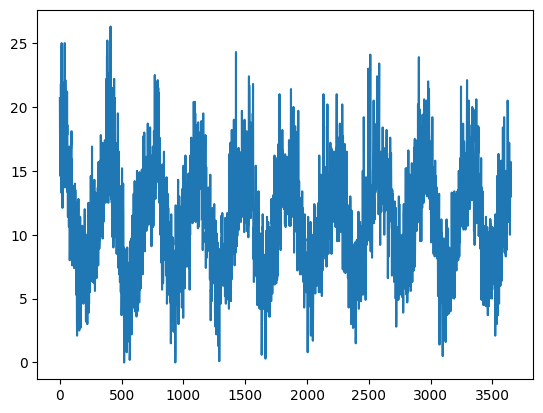

In [3]:
# visualize the data
df['Temp'].plot()
plt.show()

In [4]:
# univariate lags ('series_to_supervised')
# link: https://machinelearningmastery.com/convert-time-series-supervised-learning-problem-python/

from pandas import concat

def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
	"""
	Frame a time series as a supervised learning dataset.
	Arguments:
		data: Sequence of observations as a list or NumPy array.
		n_in: Number of lag observations as input (X).
		n_out: Number of observations as output (y).
		dropnan: Boolean whether or not to drop rows with NaN values.
	Returns:
		Pandas DataFrame of series framed for supervised learning.
	"""
	n_vars = 1 if type(data) is list else data.shape[1]
	df = pd.DataFrame(data)
	cols, names = list(), list()
	# input sequence (t-n, ... t-1)
	for i in range(n_in, 0, -1):
		cols.append(df.shift(i))
		names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
	# forecast sequence (t, t+1, ... t+n)
	for i in range(0, n_out):
		cols.append(df.shift(-i))
		if i == 0:
			names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
		else:
			names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
	# put it all together
	agg = concat(cols, axis=1)
	agg.columns = names
	# drop rows with NaN values
	if dropnan:
		agg.dropna(inplace=True)
	return agg

In [5]:
# here's what the code does for a lag of 1
values = [x for x in range(10)]
values

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [6]:
data = series_to_supervised(values, # the univariate dataset
                            n_in=1, # this means how many previous lags do you want
                            n_out=1) # this means how many steps ahead do you want to forecast (1 means current timestep)
print(data)

   var1(t-1)  var1(t)
1        0.0        1
2        1.0        2
3        2.0        3
4        3.0        4
5        4.0        5
6        5.0        6
7        6.0        7
8        7.0        8
9        8.0        9


In [7]:
# here's what the code does for a lag of 3
values = [x for x in range(10)]
data = series_to_supervised(values, # the univariate dataset
                            n_in=3, # this means how many previous lags do you want
                            n_out=1) # this means how many steps ahead do you want to forecast (1 means current timestep)
print(data)

   var1(t-3)  var1(t-2)  var1(t-1)  var1(t)
3        0.0        1.0        2.0        3
4        1.0        2.0        3.0        4
5        2.0        3.0        4.0        5
6        3.0        4.0        5.0        6
7        4.0        5.0        6.0        7
8        5.0        6.0        7.0        8
9        6.0        7.0        8.0        9


In [8]:
tmp = df['Temp']
tmp = pd.DataFrame(tmp)
tmp.head()

,Temp
0,20.7
1,17.9
2,18.8
3,14.6
4,15.8


In [9]:
# now let's use is on our datasaet
# let's use 10 lags (assume data is on a regular temporal scale)
# make sure the input is a pandas dataframe!
tmp = series_to_supervised(tmp, # the univariate dataset
                            n_in=10, # this means how many previous lags do you want
                            n_out=1)
tmp.head()

,var1(t-10),var1(t-9),var1(t-8),var1(t-7),var1(t-6),var1(t-5),var1(t-4),var1(t-3),var1(t-2),var1(t-1),var1(t)
10,20.7,17.9,18.8,14.6,15.8,15.8,15.8,17.4,21.8,20.0,16.2
11,17.9,18.8,14.6,15.8,15.8,15.8,17.4,21.8,20.0,16.2,13.3
12,18.8,14.6,15.8,15.8,15.8,17.4,21.8,20.0,16.2,13.3,16.7
13,14.6,15.8,15.8,15.8,17.4,21.8,20.0,16.2,13.3,16.7,21.5
14,15.8,15.8,15.8,17.4,21.8,20.0,16.2,13.3,16.7,21.5,25.0


In [10]:
# split data into X and Y
y = tmp['var1(t)']
X = tmp.drop(['var1(t)'], axis=1)
print(X.shape, y.shape)

(3640, 10) (3640,)


In [11]:
# now split into train and test partition
# split the data into train and test partitions
# we will use 90% of the data for train, and 10% for validation
train_pct_index = int(0.9 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

# Dense Neural Network

In [12]:
# now let's build a model

# define model
model = Sequential()
model.add(Dense(30, input_shape=(X.shape[1],), activation='relu'))
model.add(Dense(1, activation='linear'))
model.compile(optimizer='adam', loss='mse',metrics=['mae'])
model.summary()

es = EarlyStopping(monitor='val_loss', mode='min',
                   patience=5,
                   verbose=1,
                   restore_best_weights=True)

# fit model (uses early stopping)
model.fit(X_train, y_train,
          epochs=500,
          batch_size=10,
          validation_split=0.2, # val is a random 20% of the data since we set shuffle = True
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361 (1.41 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 5:53 1s/step - loss: 92.3731 - mae: 8.1877

 27/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 21.7742 - mae: 3.7950 

 53/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.5598 - mae: 3.3263

 80/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.5944 - mae: 3.1407

105/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 14.1842 - mae: 2.9865

130/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13.2321 - mae: 2.8730

157/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.5756 - mae: 2.7942

185/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12.0392 - mae: 2.7261

208/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.5976 - mae: 2.6665

236/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11.1416 - mae: 2.6075

262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 10.8077 - mae: 2.5747 - val_loss: 7.0360 - val_mae: 2.1090


Epoch 2/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 22.2994 - mae: 4.0904

 29/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.4950 - mae: 2.3551  

 58/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.2613 - mae: 2.3060

 82/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.8649 - mae: 2.2452

110/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.6758 - mae: 2.2084

137/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.4482 - mae: 2.1732

165/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.3443 - mae: 2.1517

191/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2338 - mae: 2.1310

217/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1736 - mae: 2.1194

245/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1210 - mae: 2.1095

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.0568 - mae: 2.1030 - val_loss: 6.1359 - val_mae: 1.9794


Epoch 3/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 19.7539 - mae: 3.9038

 16/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4460 - mae: 2.1685   

 39/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7463 - mae: 2.2418

 60/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4696 - mae: 2.1938

 82/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.2419 - mae: 2.1506

105/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1916 - mae: 2.1320

127/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0356 - mae: 2.1031

147/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8271 - mae: 2.0708

166/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8357 - mae: 2.0699

189/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7901 - mae: 2.0639

211/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7135 - mae: 2.0474

236/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6600 - mae: 2.0352

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5947 - mae: 2.0281

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.6038 - mae: 2.0310 - val_loss: 5.8443 - val_mae: 1.9301


Epoch 4/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:22 317ms/step - loss: 18.1383 - mae: 3.7542

 19/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1856 - mae: 2.1504     

 38/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4681 - mae: 2.1970

 56/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.4273 - mae: 2.1840

 76/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1416 - mae: 2.1361

 94/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9621 - mae: 2.0963

111/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9406 - mae: 2.0908

131/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7964 - mae: 2.0609

149/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6563 - mae: 2.0413

167/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6556 - mae: 2.0381

186/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6606 - mae: 2.0411

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5594 - mae: 2.0256

221/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5331 - mae: 2.0154

239/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4942 - mae: 2.0069

259/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4096 - mae: 1.9960

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.4451 - mae: 2.0030 - val_loss: 5.7393 - val_mae: 1.9119


Epoch 5/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 17.1715 - mae: 3.6631

 24/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2330 - mae: 2.1490   

 46/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.2368 - mae: 2.1759

 68/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1818 - mae: 2.1429

 88/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8450 - mae: 2.0820

109/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8607 - mae: 2.0782

130/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7238 - mae: 2.0478

152/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5941 - mae: 2.0326

174/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5720 - mae: 2.0267

197/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5277 - mae: 2.0178

219/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4959 - mae: 2.0098

240/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4050 - mae: 1.9911

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3611 - mae: 1.9862

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3707 - mae: 1.9891 - val_loss: 5.6811 - val_mae: 1.9009


Epoch 6/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - loss: 16.4596 - mae: 3.6027

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1289 - mae: 2.1317   

 35/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.2931 - mae: 2.1543

 49/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1818 - mae: 2.1718

 67/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1829 - mae: 2.1412

 86/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8053 - mae: 2.0751

105/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8566 - mae: 2.0708

120/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7574 - mae: 2.0526

136/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5849 - mae: 2.0257

155/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5619 - mae: 2.0236

172/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5310 - mae: 2.0179

190/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4872 - mae: 2.0103

207/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4157 - mae: 1.9984

225/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4768 - mae: 1.9992

242/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3519 - mae: 1.9817

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3200 - mae: 1.9777

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.3296 - mae: 1.9805 - val_loss: 5.6576 - val_mae: 1.8953


Epoch 7/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 31s 121ms/step - loss: 15.9908 - mae: 3.5627

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9923 - mae: 2.1183    

 40/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.2447 - mae: 2.1705

 59/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0675 - mae: 2.1276

 76/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9361 - mae: 2.1017

 93/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7992 - mae: 2.0649

110/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7933 - mae: 2.0623

127/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6734 - mae: 2.0405

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5511 - mae: 2.0190

154/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5269 - mae: 2.0175

168/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5322 - mae: 2.0141

183/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5082 - mae: 2.0146

199/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4371 - mae: 2.0003

220/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4065 - mae: 1.9911

241/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3335 - mae: 1.9773

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.3028 - mae: 1.9750 - val_loss: 5.6342 - val_mae: 1.8898


Epoch 8/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 57s 221ms/step - loss: 15.6321 - mae: 3.5311

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0106 - mae: 2.1157    

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0264 - mae: 2.1409

 66/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0523 - mae: 2.1160

 88/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7275 - mae: 2.0605

108/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7457 - mae: 2.0552

131/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5914 - mae: 2.0234

152/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4915 - mae: 2.0129

173/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4858 - mae: 2.0094

193/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4144 - mae: 1.9953

215/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3644 - mae: 1.9853

236/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3502 - mae: 1.9785

258/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2489 - mae: 1.9635

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2857 - mae: 1.9711 - val_loss: 5.6179 - val_mae: 1.8858


Epoch 9/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:39 383ms/step - loss: 15.4162 - mae: 3.5122

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0488 - mae: 2.1143     

 43/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0513 - mae: 2.1394

 66/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0350 - mae: 2.1126

 86/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7294 - mae: 2.0619

107/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7657 - mae: 2.0575

128/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6058 - mae: 2.0256

147/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4539 - mae: 2.0029

168/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5016 - mae: 2.0078

190/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4306 - mae: 1.9994

212/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3781 - mae: 1.9879

231/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3611 - mae: 1.9781

248/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2987 - mae: 1.9705

262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 6.2748 - mae: 1.9685 - val_loss: 5.6067 - val_mae: 1.8840


Epoch 10/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 29s 114ms/step - loss: 15.2508 - mae: 3.4935

 19/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7727 - mae: 2.0735    

 34/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1086 - mae: 2.1227

 54/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0100 - mae: 2.1304

 70/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9193 - mae: 2.0937

 85/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7684 - mae: 2.0696

102/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6956 - mae: 2.0443

120/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6554 - mae: 2.0338

136/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4928 - mae: 2.0080

154/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4770 - mae: 2.0075

171/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4632 - mae: 2.0041

188/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4455 - mae: 2.0010

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3819 - mae: 1.9909

223/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3995 - mae: 1.9839

242/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2884 - mae: 1.9679

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2554 - mae: 1.9633

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2643 - mae: 1.9660 - val_loss: 5.6044 - val_mae: 1.8820


Epoch 11/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 31s 120ms/step - loss: 15.1506 - mae: 3.4847

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8719 - mae: 2.0930    

 41/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1472 - mae: 2.1512

 60/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9544 - mae: 2.1090

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8124 - mae: 2.0807

 96/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7438 - mae: 2.0555

115/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5714 - mae: 2.0236

134/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5051 - mae: 2.0084

152/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4517 - mae: 2.0050

171/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4549 - mae: 2.0023

191/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3988 - mae: 1.9925

212/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3615 - mae: 1.9843

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3510 - mae: 1.9759

250/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2644 - mae: 1.9642

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2571 - mae: 1.9644 - val_loss: 5.6023 - val_mae: 1.8811


Epoch 12/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 24s 95ms/step - loss: 14.9849 - mae: 3.4635

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9118 - mae: 2.0855   

 36/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0663 - mae: 2.1112

 54/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9808 - mae: 2.1236

 71/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9213 - mae: 2.0925

 89/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6833 - mae: 2.0487

106/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7195 - mae: 2.0460

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6694 - mae: 2.0365

144/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4621 - mae: 2.0010

163/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5098 - mae: 2.0070

183/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4581 - mae: 2.0034

203/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3710 - mae: 1.9865

222/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4008 - mae: 1.9831

243/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2852 - mae: 1.9660

261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2538 - mae: 1.9632

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2509 - mae: 1.9626 - val_loss: 5.5974 - val_mae: 1.8797


Epoch 13/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 55s 214ms/step - loss: 14.8494 - mae: 3.4459

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8953 - mae: 2.0821    

 38/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1055 - mae: 2.1280

 55/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1194 - mae: 2.1279

 75/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8422 - mae: 2.0805

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7320 - mae: 2.0639

101/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6787 - mae: 2.0383

111/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6718 - mae: 2.0396

128/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5635 - mae: 2.0163

146/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4336 - mae: 1.9968

162/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5345 - mae: 2.0121

178/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4029 - mae: 1.9949

198/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3981 - mae: 1.9905

218/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3383 - mae: 1.9791

238/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3031 - mae: 1.9683

254/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2360 - mae: 1.9587

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2460 - mae: 1.9614 - val_loss: 5.5899 - val_mae: 1.8786


Epoch 14/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 14.7208 - mae: 3.4292

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8035 - mae: 2.0804   

 44/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0038 - mae: 2.1299

 62/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9935 - mae: 2.1038

 82/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7459 - mae: 2.0644

103/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7291 - mae: 2.0435

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6527 - mae: 2.0328

144/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4472 - mae: 1.9976

166/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4568 - mae: 1.9984

192/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3626 - mae: 1.9842

218/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3322 - mae: 1.9777

243/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2744 - mae: 1.9634

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2397 - mae: 1.9600 - val_loss: 5.5892 - val_mae: 1.8776


Epoch 15/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 14.6194 - mae: 3.4173

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8589 - mae: 2.0758   

 39/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1359 - mae: 2.1367

 62/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9879 - mae: 2.1027

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7136 - mae: 2.0599

104/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7419 - mae: 2.0473

125/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6285 - mae: 2.0294

145/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4213 - mae: 1.9939

165/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4659 - mae: 1.9986

186/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4514 - mae: 1.9997

207/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3247 - mae: 1.9788

227/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3665 - mae: 1.9776

249/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2605 - mae: 1.9609

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2365 - mae: 1.9591 - val_loss: 5.5870 - val_mae: 1.8770


Epoch 16/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 17s 68ms/step - loss: 14.5048 - mae: 3.3998

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7761 - mae: 2.0754   

 41/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0841 - mae: 2.1370

 60/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9021 - mae: 2.0967

 82/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7336 - mae: 2.0613

103/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7123 - mae: 2.0397

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6377 - mae: 2.0295

144/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4324 - mae: 1.9944

165/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4570 - mae: 1.9966

186/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4421 - mae: 1.9977

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3438 - mae: 1.9817

222/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3797 - mae: 1.9779

239/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2814 - mae: 1.9628

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2217 - mae: 1.9549

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2294 - mae: 1.9575 - val_loss: 5.5831 - val_mae: 1.8764


Epoch 17/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 14.4265 - mae: 3.3850

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8601 - mae: 2.0850   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9285 - mae: 2.1175

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9523 - mae: 2.0949

 86/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6577 - mae: 2.0445

106/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6805 - mae: 2.0371

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6329 - mae: 2.0286

146/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4082 - mae: 1.9914

168/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4492 - mae: 1.9953

190/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3788 - mae: 1.9873

210/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3593 - mae: 1.9812

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3216 - mae: 1.9680

254/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2172 - mae: 1.9540

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2262 - mae: 1.9567 - val_loss: 5.5783 - val_mae: 1.8758


Epoch 18/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 14.3663 - mae: 3.3729

 25/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9700 - mae: 2.0837   

 52/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9562 - mae: 2.1205

 77/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7955 - mae: 2.0742

102/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6304 - mae: 2.0287

131/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4901 - mae: 2.0022

158/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4562 - mae: 1.9995

184/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4195 - mae: 1.9943

211/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3294 - mae: 1.9749

236/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2871 - mae: 1.9629

259/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1940 - mae: 1.9496

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2200 - mae: 1.9551 - val_loss: 5.5745 - val_mae: 1.8741


Epoch 19/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - loss: 14.3012 - mae: 3.3636

 25/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9619 - mae: 2.0826   

 52/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9554 - mae: 2.1207

 79/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7039 - mae: 2.0587

101/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6434 - mae: 2.0303

121/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5558 - mae: 2.0136

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4348 - mae: 1.9947

163/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4751 - mae: 1.9991

185/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4400 - mae: 1.9969

203/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3360 - mae: 1.9785

223/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3575 - mae: 1.9734

241/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2519 - mae: 1.9576

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2124 - mae: 1.9528

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2195 - mae: 1.9553 - val_loss: 5.5761 - val_mae: 1.8744


Epoch 20/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - loss: 14.2892 - mae: 3.3595

 25/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9539 - mae: 2.0809   

 49/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9738 - mae: 2.1292

 69/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8625 - mae: 2.0780

 90/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6079 - mae: 2.0324

111/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6284 - mae: 2.0291

132/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4615 - mae: 1.9977

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3860 - mae: 1.9892

173/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4093 - mae: 1.9912

194/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3589 - mae: 1.9812

213/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3076 - mae: 1.9707

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3080 - mae: 1.9644

252/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2010 - mae: 1.9501

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2122 - mae: 1.9533 - val_loss: 5.5618 - val_mae: 1.8715


Epoch 21/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 16s 63ms/step - loss: 14.1535 - mae: 3.3329

 16/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6499 - mae: 2.0317   

 37/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0220 - mae: 2.1034

 58/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9321 - mae: 2.0989

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7418 - mae: 2.0638

100/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6580 - mae: 2.0307

123/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5561 - mae: 2.0150

145/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3838 - mae: 1.9858

166/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4203 - mae: 1.9898

189/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3780 - mae: 1.9863

212/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3084 - mae: 1.9713

235/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2858 - mae: 1.9612

258/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1749 - mae: 1.9453

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2054 - mae: 1.9521 - val_loss: 5.5581 - val_mae: 1.8706


Epoch 22/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - loss: 14.2326 - mae: 3.3467

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8664 - mae: 2.0800   

 43/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9372 - mae: 2.1115

 64/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8631 - mae: 2.0779

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6807 - mae: 2.0509

102/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6136 - mae: 2.0245

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6076 - mae: 2.0231

146/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3845 - mae: 1.9853

167/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4112 - mae: 1.9867

184/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4053 - mae: 1.9903

202/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3366 - mae: 1.9758

223/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3462 - mae: 1.9696

245/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2564 - mae: 1.9577

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2056 - mae: 1.9517 - val_loss: 5.5543 - val_mae: 1.8702


Epoch 23/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 14.2112 - mae: 3.3367

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7266 - mae: 2.0663   

 40/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0606 - mae: 2.1288

 59/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8919 - mae: 2.0914

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7360 - mae: 2.0625

 97/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6753 - mae: 2.0367

116/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4831 - mae: 2.0049

138/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4523 - mae: 1.9976

156/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4130 - mae: 1.9910

174/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4019 - mae: 1.9906

192/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3194 - mae: 1.9749

210/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3340 - mae: 1.9756

227/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3304 - mae: 1.9696

247/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2193 - mae: 1.9522

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.2006 - mae: 1.9517 - val_loss: 5.5491 - val_mae: 1.8686


Epoch 24/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:19 306ms/step - loss: 14.1147 - mae: 3.3188

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8541 - mae: 2.0774     

 44/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9404 - mae: 2.1155

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9088 - mae: 2.0845

 85/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6721 - mae: 2.0457

105/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6538 - mae: 2.0289

126/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5591 - mae: 2.0158

147/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3526 - mae: 1.9805

169/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4052 - mae: 1.9875

191/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3296 - mae: 1.9765

212/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2975 - mae: 1.9688

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2900 - mae: 1.9605

253/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1966 - mae: 1.9479

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1945 - mae: 1.9499 - val_loss: 5.5485 - val_mae: 1.8682


Epoch 25/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 14.0954 - mae: 3.3110

 20/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5810 - mae: 2.0345   

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0040 - mae: 2.1257

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9020 - mae: 2.0827

 85/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6664 - mae: 2.0439

107/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6479 - mae: 2.0302

129/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4697 - mae: 1.9962

151/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3707 - mae: 1.9854

174/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3881 - mae: 1.9869

197/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3363 - mae: 1.9767

220/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2960 - mae: 1.9649

241/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2210 - mae: 1.9504

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1835 - mae: 1.9463

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1894 - mae: 1.9486 - val_loss: 5.5405 - val_mae: 1.8672


Epoch 26/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:07 259ms/step - loss: 14.0080 - mae: 3.2947

 17/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6594 - mae: 2.0452     

 36/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9542 - mae: 2.0906

 51/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8423 - mae: 2.1050

 67/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.9679 - mae: 2.0953

 83/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6807 - mae: 2.0491

103/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6595 - mae: 2.0282

120/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5465 - mae: 2.0101

139/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4205 - mae: 1.9922

160/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4548 - mae: 1.9951

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3540 - mae: 1.9829

200/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3027 - mae: 1.9707

220/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2938 - mae: 1.9647

237/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2533 - mae: 1.9558

258/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1597 - mae: 1.9420

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1884 - mae: 1.9485 - val_loss: 5.5411 - val_mae: 1.8662


Epoch 27/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - loss: 13.9215 - mae: 3.2699

 17/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6506 - mae: 2.0431   

 36/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9415 - mae: 2.0885

 49/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9262 - mae: 2.1205

 66/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8945 - mae: 2.0808

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6504 - mae: 2.0447

103/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6510 - mae: 2.0271

121/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5073 - mae: 2.0035

138/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4277 - mae: 1.9922

156/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3869 - mae: 1.9853

175/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3787 - mae: 1.9862

193/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3020 - mae: 1.9706

213/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2752 - mae: 1.9642

233/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2743 - mae: 1.9574

253/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1866 - mae: 1.9458

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1838 - mae: 1.9478 - val_loss: 5.5422 - val_mae: 1.8666


Epoch 28/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 28s 108ms/step - loss: 13.9682 - mae: 3.2859

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7616 - mae: 2.0571    

 35/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9981 - mae: 2.0947

 52/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8945 - mae: 2.1078

 68/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8933 - mae: 2.0832

 85/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6521 - mae: 2.0413

103/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6453 - mae: 2.0256

122/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5117 - mae: 2.0055

140/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3861 - mae: 1.9857

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3438 - mae: 1.9801

164/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4102 - mae: 1.9848

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3430 - mae: 1.9807

197/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3212 - mae: 1.9741

214/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2559 - mae: 1.9603

231/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2644 - mae: 1.9550

250/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1895 - mae: 1.9462

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.1794 - mae: 1.9467 - val_loss: 5.5376 - val_mae: 1.8676


Epoch 29/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - loss: 13.9361 - mae: 3.2755

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8172 - mae: 2.0737   

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9793 - mae: 2.1227

 62/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9081 - mae: 2.0853

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6424 - mae: 2.0429

104/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6654 - mae: 2.0310

122/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5063 - mae: 2.0050

141/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3877 - mae: 1.9855

161/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4431 - mae: 1.9922

182/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3533 - mae: 1.9821

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2780 - mae: 1.9678

225/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3230 - mae: 1.9650

245/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2235 - mae: 1.9509

251/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1755 - mae: 1.9438

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1744 - mae: 1.9455 - val_loss: 5.5306 - val_mae: 1.8646


Epoch 30/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:21 312ms/step - loss: 13.8663 - mae: 3.2611

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8129 - mae: 2.0718     

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9740 - mae: 2.1211

 63/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8514 - mae: 2.0755

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6364 - mae: 2.0411

104/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6595 - mae: 2.0294

121/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4917 - mae: 2.0003

138/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4102 - mae: 1.9886

155/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3612 - mae: 1.9807

175/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3631 - mae: 1.9830

192/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2806 - mae: 1.9670

209/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3041 - mae: 1.9685

229/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2860 - mae: 1.9590

250/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1808 - mae: 1.9444

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1705 - mae: 1.9448 - val_loss: 5.5318 - val_mae: 1.8663


Epoch 31/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - loss: 13.8574 - mae: 3.2539

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8055 - mae: 2.0721   

 44/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9000 - mae: 2.1107

 64/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8151 - mae: 2.0702

 81/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6993 - mae: 2.0487

 96/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6163 - mae: 2.0273

116/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4413 - mae: 1.9964

135/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3616 - mae: 1.9797

155/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3571 - mae: 1.9804

175/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3593 - mae: 1.9825

197/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3061 - mae: 1.9714

217/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2489 - mae: 1.9590

239/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2184 - mae: 1.9487

260/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1649 - mae: 1.9422

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1693 - mae: 1.9444 - val_loss: 5.5323 - val_mae: 1.8665


Epoch 32/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:23 321ms/step - loss: 13.8919 - mae: 3.2504

 14/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.5557 - mae: 2.0125     

 31/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.0947 - mae: 2.1139

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8321 - mae: 2.0997

 60/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.8051 - mae: 2.0781

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6891 - mae: 2.0527

 94/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5762 - mae: 2.0194

112/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5212 - mae: 2.0072

128/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4562 - mae: 1.9948

146/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3268 - mae: 1.9749

165/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3768 - mae: 1.9798

182/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3387 - mae: 1.9796

200/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2713 - mae: 1.9651

218/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2486 - mae: 1.9595

237/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2265 - mae: 1.9503

256/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1624 - mae: 1.9418

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1647 - mae: 1.9437 - val_loss: 5.5258 - val_mae: 1.8640


Epoch 33/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - loss: 13.7196 - mae: 3.2065

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7552 - mae: 2.0676   

 44/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8827 - mae: 2.1068

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8597 - mae: 2.0759

 83/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6460 - mae: 2.0422

103/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6200 - mae: 2.0214

123/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4941 - mae: 2.0034

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3555 - mae: 1.9788

163/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3997 - mae: 1.9832

185/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3669 - mae: 1.9823

209/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2925 - mae: 1.9659

233/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2483 - mae: 1.9512

255/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1520 - mae: 1.9402

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1609 - mae: 1.9426 - val_loss: 5.5209 - val_mae: 1.8627


Epoch 34/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 16s 62ms/step - loss: 13.7470 - mae: 3.2101

 25/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8694 - mae: 2.0677   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8199 - mae: 2.0966

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8539 - mae: 2.0741

 87/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5589 - mae: 2.0240

108/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5621 - mae: 2.0152

134/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3690 - mae: 1.9798

156/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3509 - mae: 1.9784

177/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3198 - mae: 1.9756

197/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2934 - mae: 1.9683

215/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2231 - mae: 1.9535

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2485 - mae: 1.9511

252/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1488 - mae: 1.9385

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1573 - mae: 1.9414 - val_loss: 5.5173 - val_mae: 1.8627


Epoch 35/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 13.7684 - mae: 3.2193

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7454 - mae: 2.0673   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8095 - mae: 2.0956

 66/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8502 - mae: 2.0726

 87/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5526 - mae: 2.0234

106/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5851 - mae: 2.0180

123/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4829 - mae: 2.0012

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3454 - mae: 1.9768

163/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3904 - mae: 1.9813

184/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3358 - mae: 1.9779

204/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2540 - mae: 1.9620

226/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2966 - mae: 1.9604

248/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1820 - mae: 1.9425

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1558 - mae: 1.9412 - val_loss: 5.5232 - val_mae: 1.8631


Epoch 36/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 13.7311 - mae: 3.2173

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7511 - mae: 2.0665   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8153 - mae: 2.0964

 67/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9178 - mae: 2.0861

 89/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5503 - mae: 2.0196

110/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5795 - mae: 2.0170

130/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4170 - mae: 1.9879

150/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2890 - mae: 1.9698

168/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3613 - mae: 1.9766

189/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3095 - mae: 1.9726

209/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2843 - mae: 1.9637

226/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2942 - mae: 1.9596

248/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1802 - mae: 1.9418

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1532 - mae: 1.9404 - val_loss: 5.5212 - val_mae: 1.8631


Epoch 37/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - loss: 13.7308 - mae: 3.2174

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6270 - mae: 2.0507   

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9340 - mae: 2.1149

 61/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8604 - mae: 2.0747

 79/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6125 - mae: 2.0382

101/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5444 - mae: 2.0097

123/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4769 - mae: 1.9996

144/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3266 - mae: 1.9729

165/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3595 - mae: 1.9754

188/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3091 - mae: 1.9713

210/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2766 - mae: 1.9625

230/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2535 - mae: 1.9516

253/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1547 - mae: 1.9381

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1504 - mae: 1.9398 - val_loss: 5.5197 - val_mae: 1.8627


Epoch 38/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - loss: 13.7236 - mae: 3.2181

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7100 - mae: 2.0476   

 36/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8918 - mae: 2.0830

 50/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8072 - mae: 2.0998

 67/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9081 - mae: 2.0848

 86/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5597 - mae: 2.0230

104/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6243 - mae: 2.0237

119/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4829 - mae: 2.0014

139/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3581 - mae: 1.9810

161/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4032 - mae: 1.9849

183/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3340 - mae: 1.9776

202/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2575 - mae: 1.9610

222/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2904 - mae: 1.9581

240/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1794 - mae: 1.9407

261/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1504 - mae: 1.9401

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1463 - mae: 1.9393 - val_loss: 5.5151 - val_mae: 1.8614


Epoch 39/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 13.6871 - mae: 3.2147

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6158 - mae: 2.0481   

 44/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8509 - mae: 2.1004

 66/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8339 - mae: 2.0684

 90/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5084 - mae: 2.0117

114/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4299 - mae: 1.9907

136/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3220 - mae: 1.9724

157/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3351 - mae: 1.9757

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2970 - mae: 1.9714

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2380 - mae: 1.9592

228/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2631 - mae: 1.9533

252/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1351 - mae: 1.9353

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1437 - mae: 1.9384 - val_loss: 5.5107 - val_mae: 1.8601


Epoch 40/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 48ms/step - loss: 13.6211 - mae: 3.2091

 24/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7860 - mae: 2.0611   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7891 - mae: 2.0913

 66/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8316 - mae: 2.0687

 88/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5197 - mae: 2.0155

111/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5292 - mae: 2.0096

132/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3626 - mae: 1.9787

156/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3266 - mae: 1.9741

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2934 - mae: 1.9712

200/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2418 - mae: 1.9586

221/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2289 - mae: 1.9508

242/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1604 - mae: 1.9381

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1398 - mae: 1.9379 - val_loss: 5.5103 - val_mae: 1.8607


Epoch 41/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 13.6640 - mae: 3.2221

 24/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7844 - mae: 2.0618   

 47/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9571 - mae: 2.1189

 70/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7341 - mae: 2.0533

 88/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5163 - mae: 2.0147

106/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5593 - mae: 2.0127

126/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4779 - mae: 2.0006

144/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3078 - mae: 1.9697

164/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3555 - mae: 1.9745

184/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3158 - mae: 1.9737

206/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2148 - mae: 1.9559

229/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2496 - mae: 1.9505

252/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1295 - mae: 1.9342

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1375 - mae: 1.9372 - val_loss: 5.5068 - val_mae: 1.8597


Epoch 42/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 49ms/step - loss: 13.6131 - mae: 3.2074

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7158 - mae: 2.0599   

 47/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9470 - mae: 2.1165

 72/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7384 - mae: 2.0515

 92/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5129 - mae: 2.0121

110/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5508 - mae: 2.0111

129/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3921 - mae: 1.9815

150/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2609 - mae: 1.9641

168/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3383 - mae: 1.9716

190/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2647 - mae: 1.9635

211/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2342 - mae: 1.9537

226/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2729 - mae: 1.9547

245/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1789 - mae: 1.9407

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1330 - mae: 1.9361 - val_loss: 5.5058 - val_mae: 1.8588


Epoch 43/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 13.5975 - mae: 3.2084

 25/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8355 - mae: 2.0595   

 49/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8385 - mae: 2.1028

 70/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7215 - mae: 2.0510

 93/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5544 - mae: 2.0141

117/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3898 - mae: 1.9861

138/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3525 - mae: 1.9784

162/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3916 - mae: 1.9822

182/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2976 - mae: 1.9710

204/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2252 - mae: 1.9565

228/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2459 - mae: 1.9507

257/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1167 - mae: 1.9331

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1255 - mae: 1.9355 - val_loss: 5.5005 - val_mae: 1.8587


Epoch 44/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 13.6557 - mae: 3.2103

 26/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9170 - mae: 2.0600   

 47/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9392 - mae: 2.1137

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8091 - mae: 2.0662

 82/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6128 - mae: 2.0339

100/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5462 - mae: 2.0093

118/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3989 - mae: 1.9892

138/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3498 - mae: 1.9779

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2748 - mae: 1.9673

170/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3163 - mae: 1.9719

188/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2836 - mae: 1.9670

207/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1971 - mae: 1.9527

224/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2580 - mae: 1.9513

244/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1611 - mae: 1.9378

262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1244 - mae: 1.9353

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1244 - mae: 1.9353 - val_loss: 5.5003 - val_mae: 1.8575


Epoch 45/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 22s 88ms/step - loss: 13.6472 - mae: 3.2154

 20/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4551 - mae: 2.0122   

 41/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9132 - mae: 2.1041

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8037 - mae: 2.0655

 88/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4972 - mae: 2.0117

113/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4346 - mae: 1.9918

138/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3435 - mae: 1.9769

159/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3590 - mae: 1.9784

181/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3046 - mae: 1.9725

203/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2212 - mae: 1.9553

227/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2473 - mae: 1.9511

254/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1220 - mae: 1.9331

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1246 - mae: 1.9351 - val_loss: 5.5012 - val_mae: 1.8576


Epoch 46/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - loss: 13.6097 - mae: 3.2186

 27/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9611 - mae: 2.0705   

 50/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7736 - mae: 2.0923

 70/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7118 - mae: 2.0490

 93/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5411 - mae: 2.0108

118/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3890 - mae: 1.9868

142/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3070 - mae: 1.9697

167/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2993 - mae: 1.9649

194/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2479 - mae: 1.9592

219/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2401 - mae: 1.9533

245/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1681 - mae: 1.9386

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1215 - mae: 1.9340 - val_loss: 5.4973 - val_mae: 1.8573


Epoch 47/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:15 520ms/step - loss: 13.5847 - mae: 3.2118

 24/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7624 - mae: 2.0543     

 46/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8288 - mae: 2.0943

 68/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8083 - mae: 2.0677

 93/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5369 - mae: 2.0103

118/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3848 - mae: 1.9861

142/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3026 - mae: 1.9693

168/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3219 - mae: 1.9692

192/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2176 - mae: 1.9547

216/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1834 - mae: 1.9454

239/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1654 - mae: 1.9371

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1163 - mae: 1.9334 - val_loss: 5.4945 - val_mae: 1.8569


Epoch 48/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:11 503ms/step - loss: 13.6410 - mae: 3.2240

 28/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.1540 - mae: 2.1031     

 55/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9135 - mae: 2.0869

 81/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6293 - mae: 2.0329

105/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5432 - mae: 2.0073

129/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3657 - mae: 1.9762

152/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2694 - mae: 1.9657

174/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3000 - mae: 1.9687

199/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2241 - mae: 1.9541

219/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2343 - mae: 1.9516

242/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1359 - mae: 1.9322

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1144 - mae: 1.9321 - val_loss: 5.4963 - val_mae: 1.8567


Epoch 49/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 13.6009 - mae: 3.2299

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6460 - mae: 2.0352   

 38/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8929 - mae: 2.0896

 57/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8115 - mae: 2.0740

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6175 - mae: 2.0377

 99/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5194 - mae: 2.0045

118/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3745 - mae: 1.9832

139/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3117 - mae: 1.9712

159/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3443 - mae: 1.9746

179/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2459 - mae: 1.9617

201/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2177 - mae: 1.9525

223/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2442 - mae: 1.9475

244/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1502 - mae: 1.9344

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1117 - mae: 1.9319 - val_loss: 5.4889 - val_mae: 1.8558


Epoch 50/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 15s 60ms/step - loss: 13.6196 - mae: 3.2333

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6822 - mae: 2.0510   

 43/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7770 - mae: 2.0798

 65/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7788 - mae: 2.0599

 87/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4873 - mae: 2.0095

108/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4889 - mae: 2.0012

129/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3558 - mae: 1.9746

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2501 - mae: 1.9611

177/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2626 - mae: 1.9637

199/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2150 - mae: 1.9525

222/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2523 - mae: 1.9488

242/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1294 - mae: 1.9309

262/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1074 - mae: 1.9308

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.1074 - mae: 1.9308 - val_loss: 5.4902 - val_mae: 1.8560


Epoch 51/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 13.6088 - mae: 3.2304

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6986 - mae: 2.0488   

 47/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9042 - mae: 2.1063

 72/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7021 - mae: 2.0457

 97/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5330 - mae: 2.0086

122/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4023 - mae: 1.9850

147/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2307 - mae: 1.9566

170/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2897 - mae: 1.9656

193/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2071 - mae: 1.9511

219/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2233 - mae: 1.9493

243/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1368 - mae: 1.9319

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1036 - mae: 1.9298 - val_loss: 5.4896 - val_mae: 1.8567


Epoch 52/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:24 555ms/step - loss: 13.6216 - mae: 3.2421

 30/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9688 - mae: 2.0820     

 62/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7989 - mae: 2.0647

 92/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4699 - mae: 2.0044

120/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4238 - mae: 1.9867

151/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2541 - mae: 1.9626

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2509 - mae: 1.9624

209/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2330 - mae: 1.9532

238/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1540 - mae: 1.9334

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.1018 - mae: 1.9295 - val_loss: 5.4899 - val_mae: 1.8561


Epoch 53/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 11s 44ms/step - loss: 13.6384 - mae: 3.2469

 31/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9845 - mae: 2.0919   

 61/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7945 - mae: 2.0613

 92/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4668 - mae: 2.0035

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4597 - mae: 1.9946

159/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3310 - mae: 1.9722

194/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2230 - mae: 1.9544

230/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2023 - mae: 1.9408

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.0962 - mae: 1.9288 - val_loss: 5.4850 - val_mae: 1.8558


Epoch 54/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 13.6481 - mae: 3.2517

 30/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9571 - mae: 2.0787   

 62/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7926 - mae: 2.0628

 92/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4594 - mae: 2.0022

123/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3957 - mae: 1.9839

148/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2184 - mae: 1.9538

171/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2677 - mae: 1.9619

190/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2196 - mae: 1.9550

211/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1963 - mae: 1.9463

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1849 - mae: 1.9364

256/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0956 - mae: 1.9265

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0942 - mae: 1.9280 - val_loss: 5.4866 - val_mae: 1.8555


Epoch 55/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:23 549ms/step - loss: 13.6571 - mae: 3.2567

 24/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7248 - mae: 2.0440     

 46/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7888 - mae: 2.0841

 68/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7741 - mae: 2.0600

 90/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4385 - mae: 1.9980

113/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3942 - mae: 1.9822

134/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2779 - mae: 1.9613

155/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2614 - mae: 1.9599

177/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2459 - mae: 1.9598

200/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1889 - mae: 1.9471

222/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2364 - mae: 1.9450

245/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1396 - mae: 1.9316

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0906 - mae: 1.9266 - val_loss: 5.4840 - val_mae: 1.8558


Epoch 56/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 13.6592 - mae: 3.2599

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6568 - mae: 2.0450   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7088 - mae: 2.0719

 69/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6880 - mae: 2.0421

 96/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4999 - mae: 2.0035

120/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4046 - mae: 1.9826

140/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2622 - mae: 1.9621

160/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3286 - mae: 1.9701

182/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2531 - mae: 1.9616

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1778 - mae: 1.9475

227/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2102 - mae: 1.9425

248/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1127 - mae: 1.9272

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0854 - mae: 1.9263 - val_loss: 5.4861 - val_mae: 1.8561


Epoch 57/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:48 417ms/step - loss: 13.6989 - mae: 3.2632

 24/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7173 - mae: 2.0417     

 47/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8817 - mae: 2.1004

 71/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6868 - mae: 2.0421

 95/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5173 - mae: 2.0051

120/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4031 - mae: 1.9818

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2551 - mae: 1.9581

166/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2749 - mae: 1.9585

191/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1961 - mae: 1.9491

214/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1569 - mae: 1.9388

239/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1358 - mae: 1.9294

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0844 - mae: 1.9255 - val_loss: 5.4854 - val_mae: 1.8545


Epoch 58/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 14s 54ms/step - loss: 13.6662 - mae: 3.2575

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5288 - mae: 2.0252   

 41/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8553 - mae: 2.0892

 64/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6945 - mae: 2.0439

 89/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4485 - mae: 1.9987

113/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3808 - mae: 1.9791

136/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2421 - mae: 1.9563

160/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3237 - mae: 1.9680

185/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2746 - mae: 1.9629

210/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2088 - mae: 1.9481

234/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1526 - mae: 1.9297

257/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0758 - mae: 1.9225

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0814 - mae: 1.9245 - val_loss: 5.4868 - val_mae: 1.8549


Epoch 59/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:10 498ms/step - loss: 13.6643 - mae: 3.2639

 26/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8619 - mae: 2.0444     

 51/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6888 - mae: 2.0726

 75/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6227 - mae: 2.0321

 97/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4952 - mae: 1.9998

119/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3899 - mae: 1.9806

142/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2530 - mae: 1.9576

162/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3359 - mae: 1.9691

184/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2481 - mae: 1.9590

205/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1674 - mae: 1.9447

229/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1912 - mae: 1.9364

254/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0775 - mae: 1.9218

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0782 - mae: 1.9235 - val_loss: 5.4877 - val_mae: 1.8558


Epoch 60/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:03 473ms/step - loss: 13.6976 - mae: 3.2624

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6384 - mae: 2.0386     

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8304 - mae: 2.0887

 63/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7194 - mae: 2.0474

 86/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4678 - mae: 2.0008

109/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4448 - mae: 1.9926

133/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2545 - mae: 1.9569

158/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2819 - mae: 1.9627

182/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2426 - mae: 1.9583

207/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1447 - mae: 1.9405

230/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1826 - mae: 1.9349

257/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0715 - mae: 1.9214

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0769 - mae: 1.9233 - val_loss: 5.4819 - val_mae: 1.8558


Epoch 61/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - loss: 13.7238 - mae: 3.2790

 29/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0240 - mae: 2.0844   

 59/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7077 - mae: 2.0543

 84/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5040 - mae: 2.0134

108/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4425 - mae: 1.9915

130/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3047 - mae: 1.9654

149/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1833 - mae: 1.9470

171/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2446 - mae: 1.9567

194/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1912 - mae: 1.9478

217/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1477 - mae: 1.9375

242/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0958 - mae: 1.9234

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0725 - mae: 1.9230 - val_loss: 5.4871 - val_mae: 1.8570


Epoch 62/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 51ms/step - loss: 13.7459 - mae: 3.2703

 26/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8513 - mae: 2.0418   

 48/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8227 - mae: 2.0933

 70/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6419 - mae: 2.0325

 92/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4284 - mae: 1.9945

110/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4643 - mae: 1.9932

124/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4221 - mae: 1.9857

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2333 - mae: 1.9537

162/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3266 - mae: 1.9681

178/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2020 - mae: 1.9525

195/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1908 - mae: 1.9474

214/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1403 - mae: 1.9357

233/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1556 - mae: 1.9299

250/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0807 - mae: 1.9217

262/262 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 6.0686 - mae: 1.9225 - val_loss: 5.4854 - val_mae: 1.8564


Epoch 63/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - loss: 13.7654 - mae: 3.2737

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6278 - mae: 2.0370   

 43/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7340 - mae: 2.0678

 62/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7572 - mae: 2.0542

 80/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5127 - mae: 2.0169

 97/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4789 - mae: 1.9957

113/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3611 - mae: 1.9740

133/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2396 - mae: 1.9536

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2025 - mae: 1.9499

176/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2346 - mae: 1.9563

194/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1838 - mae: 1.9453

213/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1502 - mae: 1.9369

232/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1571 - mae: 1.9295

253/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0723 - mae: 1.9195

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0649 - mae: 1.9210 - val_loss: 5.4806 - val_mae: 1.8553


Epoch 64/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - loss: 13.7430 - mae: 3.2638

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4970 - mae: 2.0168   

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8227 - mae: 2.0860

 64/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6758 - mae: 2.0383

 85/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5015 - mae: 2.0074

109/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4279 - mae: 1.9887

133/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2349 - mae: 1.9524

160/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3031 - mae: 1.9633

189/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2064 - mae: 1.9504

217/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1375 - mae: 1.9346

246/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0960 - mae: 1.9225

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0615 - mae: 1.9202 - val_loss: 5.4794 - val_mae: 1.8556


Epoch 65/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 13.7561 - mae: 3.2750

 31/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9345 - mae: 2.0787   

 61/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.7475 - mae: 2.0490

 89/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4228 - mae: 1.9927

117/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3003 - mae: 1.9648

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2223 - mae: 1.9504

169/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2529 - mae: 1.9549

195/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1811 - mae: 1.9447

226/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2006 - mae: 1.9383

253/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0660 - mae: 1.9181

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0584 - mae: 1.9195 - val_loss: 5.4767 - val_mae: 1.8558


Epoch 66/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 13.7600 - mae: 3.2749

 30/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.9124 - mae: 2.0671  

 60/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6622 - mae: 2.0465

 87/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4262 - mae: 1.9950

118/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3065 - mae: 1.9676

152/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2024 - mae: 1.9515

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2016 - mae: 1.9516

208/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1718 - mae: 1.9419

234/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1272 - mae: 1.9245

257/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0498 - mae: 1.9174

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0550 - mae: 1.9192 - val_loss: 5.4770 - val_mae: 1.8568


Epoch 67/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 50ms/step - loss: 13.7379 - mae: 3.2741

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6075 - mae: 2.0354   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6666 - mae: 2.0624

 69/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6410 - mae: 2.0306

 91/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3986 - mae: 1.9875

110/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4422 - mae: 1.9880

127/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3317 - mae: 1.9705

146/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1898 - mae: 1.9459

165/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2553 - mae: 1.9529

185/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2421 - mae: 1.9556

207/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1185 - mae: 1.9354

231/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1360 - mae: 1.9251

255/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0494 - mae: 1.9164

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0524 - mae: 1.9181 - val_loss: 5.4764 - val_mae: 1.8568


Epoch 68/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 16s 64ms/step - loss: 13.7628 - mae: 3.2808

 19/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3941 - mae: 2.0011   

 37/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8055 - mae: 2.0636

 56/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8143 - mae: 2.0703

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5405 - mae: 2.0201

 98/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4629 - mae: 1.9926

116/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2889 - mae: 1.9633

133/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2200 - mae: 1.9503

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1870 - mae: 1.9478

173/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2248 - mae: 1.9524

194/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1686 - mae: 1.9426

215/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1128 - mae: 1.9295

234/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1222 - mae: 1.9229

254/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0503 - mae: 1.9160

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0500 - mae: 1.9177 - val_loss: 5.4758 - val_mae: 1.8563


Epoch 69/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 13.7551 - mae: 3.2819

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6097 - mae: 2.0369   

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8073 - mae: 2.0856

 59/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6809 - mae: 2.0492

 72/262 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6.6285 - mae: 2.0297

 99/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4326 - mae: 1.9871

125/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.3775 - mae: 1.9790

153/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1822 - mae: 1.9477

179/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1741 - mae: 1.9471

207/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1101 - mae: 1.9346

231/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1277 - mae: 1.9243

254/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0446 - mae: 1.9157

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0444 - mae: 1.9174 - val_loss: 5.4750 - val_mae: 1.8564


Epoch 70/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:47 410ms/step - loss: 13.7418 - mae: 3.2779

 18/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5604 - mae: 2.0224     

 36/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7758 - mae: 2.0579

 58/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7210 - mae: 2.0558

 81/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5465 - mae: 2.0144

104/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4930 - mae: 1.9950

128/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2998 - mae: 1.9617

150/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1543 - mae: 1.9410

172/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2179 - mae: 1.9509

193/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1423 - mae: 1.9378

215/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1067 - mae: 1.9286

235/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1181 - mae: 1.9227

253/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0515 - mae: 1.9154

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0423 - mae: 1.9166 - val_loss: 5.4693 - val_mae: 1.8553


Epoch 71/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 12s 46ms/step - loss: 13.7432 - mae: 3.2807

 26/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8292 - mae: 2.0404   

 51/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6623 - mae: 2.0689

 74/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5668 - mae: 2.0215

 97/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4530 - mae: 1.9915

119/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3474 - mae: 1.9727

143/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2040 - mae: 1.9478

167/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2184 - mae: 1.9478

190/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1639 - mae: 1.9431

214/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1124 - mae: 1.9302

240/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0786 - mae: 1.9183

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0400 - mae: 1.9166 - val_loss: 5.4782 - val_mae: 1.8575


Epoch 72/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 2:13 511ms/step - loss: 13.7143 - mae: 3.2668

 26/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8179 - mae: 2.0374     

 50/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6748 - mae: 2.0700

 72/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6153 - mae: 2.0258

 94/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4093 - mae: 1.9839

118/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2897 - mae: 1.9641

140/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2069 - mae: 1.9499

164/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2588 - mae: 1.9532

186/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2241 - mae: 1.9523

209/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1757 - mae: 1.9412

234/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1175 - mae: 1.9220

258/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0217 - mae: 1.9112

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.0421 - mae: 1.9163 - val_loss: 5.4760 - val_mae: 1.8572


Epoch 73/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - loss: 13.8510 - mae: 3.2952

 23/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6103 - mae: 2.0392   

 45/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6588 - mae: 2.0623

 64/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6461 - mae: 2.0347

 87/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.4005 - mae: 1.9910

112/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.3536 - mae: 1.9723

135/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1834 - mae: 1.9435

158/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2345 - mae: 1.9535

181/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2055 - mae: 1.9502

201/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1340 - mae: 1.9363

224/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.1657 - mae: 1.9304

249/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.0580 - mae: 1.9157

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0323 - mae: 1.9151 - val_loss: 5.4823 - val_mae: 1.8578


Epoch 74/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 1:13 282ms/step - loss: 13.7333 - mae: 3.2714

 21/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4656 - mae: 2.0144     

 41/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8199 - mae: 2.0830

 61/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7202 - mae: 2.0442

 78/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.5205 - mae: 2.0161

 98/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4445 - mae: 1.9883

115/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2843 - mae: 1.9612

133/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1978 - mae: 1.9451

145/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1600 - mae: 1.9387

167/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2061 - mae: 1.9442

183/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2044 - mae: 1.9489

203/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1228 - mae: 1.9345

225/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1754 - mae: 1.9319

247/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0525 - mae: 1.9144

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0298 - mae: 1.9139 - val_loss: 5.4809 - val_mae: 1.8574


Epoch 75/500


  1/262 ━━━━━━━━━━━━━━━━━━━━ 17s 67ms/step - loss: 13.7922 - mae: 3.2757

 22/262 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5975 - mae: 2.0321   

 42/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.7879 - mae: 2.0828

 60/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.6318 - mae: 2.0415

 79/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4595 - mae: 2.0063

 96/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4243 - mae: 1.9876

114/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2870 - mae: 1.9611

133/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1948 - mae: 1.9457

150/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1387 - mae: 1.9387

164/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.2458 - mae: 1.9512

180/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1781 - mae: 1.9470

198/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1558 - mae: 1.9412

214/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1024 - mae: 1.9289

233/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.1197 - mae: 1.9233

249/262 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.0556 - mae: 1.9163

262/262 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0277 - mae: 1.9153 - val_loss: 5.4768 - val_mae: 1.8549


Epoch 75: early stopping


Restoring model weights from the end of the best epoch: 70.


 1/12 ━━━━━━━━━━━━━━━━━━━━ 1s 127ms/step

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step  

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


MAE:  1.7997635246633177


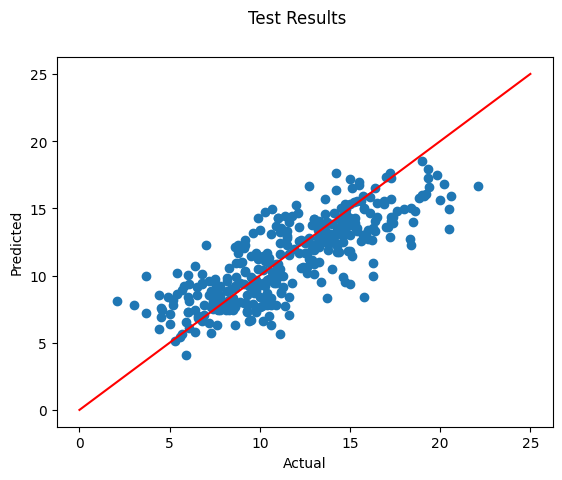

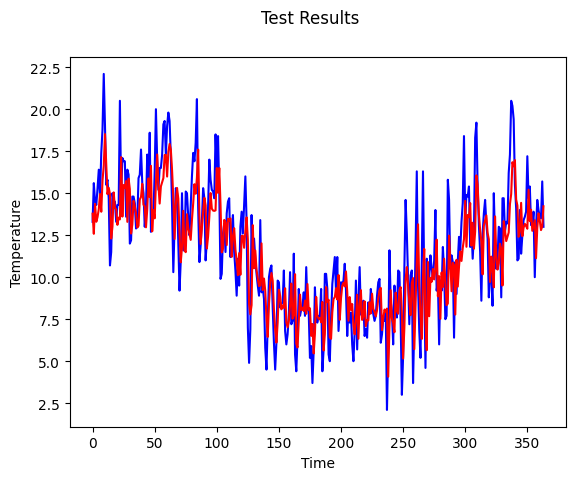

In [13]:
# show scatterplots of actual vs. predicted for train and test
# make a prediction
pred = model.predict(X_test)# the pred

# calculate MSE for the baseline model
from sklearn.metrics import mean_absolute_error
print('MAE: ', mean_absolute_error(y_test, pred))

actual = y_test # the actual
plt.scatter(x=actual, y=pred)
x = np.linspace(0,25) # 45 degree line from 0 to 25 (axes are the same)
plt.plot(x, x, color='red')
plt.suptitle('Test Results')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.show()
# looks pretty good!

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.show()

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [14]:
from keras.models import load_model

model.save('Univariate_Temperature_Lags.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Univariate_Temperature_Lags.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           330 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,085 (4.24 KB)

 Trainable params: 361 (1.41 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 724 (2.83 KB)

Of course, you could play around with more lags and even try polynomial features or other scaling to get this to work. Heck, once your data is prepped, you can even try TPOT to see if you can get a better architecture then what you are evaluating.